# Chunk 44 — Train, validate and test the surrogate on 15×15

Same design as Chunk 42 (12×12), on the Chunk 43 dataset: pool 5,092, val 638, test 637. Labels use `LABEL_MIN` throughout.

**Arms:**

| arm | starts from | trains on |
|---|---|---|
| `ft15` | `backbone_no55` (25/35/45) | 15×15 pool only |
| `ft15_replay` | `backbone_no55` | 15×15 pool, plus 25/35/45 replay |
| `ft15_from4` | **the Chunk 42 four-grid model** (12/25/35/45) | 15×15 pool only |
| `ft15_from4_replay` | the four-grid model | 15×15 pool, plus 12/25/35/45 replay: **one model for all five grids** |
| `scratch15` | random | 15×15 pool only (same GNN; Chunk 7 recipe) |
| `cnn15` | random | 15×15 pool only: Gupta et al. CNN at 15×15, 63.5 M parameters (Chunk 36 recipe) |

The fine-tune arms use Adam lr 1e-4, batch 64, patience 10. Replay draws 5,092 antennas per grid per epoch, the same count as the 15×15 pool.

**Run queue, in priority order:**
1. every arm at 100%, seed 0
2. `ft15`, `ft15_from4`, `scratch15` and `cnn15` at 100%, seed 1
3. `ft15` and `scratch15` at 25% and 50% of the pool

**Protocol:**
- **Selection:** every arm on 15×15 val MSE in raw dB.
- **Test:** touched once. The 100% seed-0 fine-tunes are also tested on 12/25/35/45 for forgetting.
- **Intervals:** paired stratified-bootstrap intervals.

**Pre-registered statements:**

| | question |
|---|---|
| S0 | **Zero-shot interpolation, on test:** does the four-grid model beat `backbone_no55` on 15×15, a grid neither has seen? (Chunk 43 showed this on val: 2.11 against 3.23 dB².) |
| S0b | How does that zero-shot model compare with a GNN *trained* on 15×15 from scratch? |
| S1 | **Transfer:** does fine-tuning beat training from scratch? |
| S2 | **Data:** does fine-tuning on 25% or 50% of the pool beat training from scratch on 100%? |
| S3 | **Forgetting:** with and without replay, against each arm's starting model. |
| S4 | **GNN against the Gupta CNN** on 15×15. |
| S5 | **Starting point:** does the four-grid model beat `backbone_no55` as a starting point? |
| S6 | The best 15×15 arm, with its skill. |

**Writes:** only `ch44_*` artifacts and `checkpoints/ch44_*.pt`. Each checkpoint is force-flushed to Drive and SHA-verified.

## 1. Installs

In [1]:
!pip -q install torch_geometric pyarrow tabulate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.8 MB/s eta 0:00:00


## 2. Repository and Drive

In [2]:
import os, sys, subprocess
REPO_ROOT = '/content/antenna_gnn'
if os.path.isdir(f'{REPO_ROOT}/.git'):
    subprocess.run(['git', '-C', REPO_ROOT, 'pull', '-q'], check=True)
else:
    subprocess.run(['git', 'clone', '-q', 'https://github.com/asparagusD/antenna_gnn.git', REPO_ROOT], check=True)
sys.path.insert(0, f'{REPO_ROOT}/src')
from google.colab import drive
drive.mount('/content/drive')
DATA_ROOT = '/content/drive/MyDrive/antenna_gnn'
ART, CKPT, SPLITS, LOCAL = f'{DATA_ROOT}/artifacts', f'{DATA_ROOT}/checkpoints', f'{DATA_ROOT}/splits', '/content/local_graphs'
os.makedirs(LOCAL, exist_ok=True)
print(REPO_ROOT, DATA_ROOT)

Mounted at /content/drive
/content/antenna_gnn /content/drive/MyDrive/antenna_gnn


## 3. Setup
**What it does:**
- Enables deterministic cuDNN and turns TF32 off.
- Hashes the input files and captures the mtimes of earlier ones.
- Loads the canonical 25×25 statistics read-only.
- **Requires both Chunk 43's and Chunk 41's builder checks to say "bit-identical",** and the Chunk 42 four-grid checkpoint to exist.

In [3]:
# ── Setup: scope, provenance, determinism ──
import json, glob, hashlib, zipfile, shutil, time, math
from pathlib import Path
import numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader as TorchLoader
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoLoader
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from model import AntennaGNN
from feed_component import AppendFeedComponentFeature

TAU, F = -10.0, np.linspace(1, 4, 201)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu'); assert DEVICE.type == 'cuda', 'GPU required'
torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
torch.backends.cuda.matmul.allow_tf32 = False; torch.backends.cudnn.allow_tf32 = False
def sha(p):
    h = hashlib.sha256()
    with open(p, 'rb') as f:
        for b in iter(lambda: f.read(1 << 20), b''):
            h.update(b)
    return h.hexdigest()
READ_SHA = {}
def READ(p):
    assert os.path.exists(p), f'missing {p}'
    READ_SHA.setdefault(p, sha(p)); return p
def OUT(n):
    assert n.startswith('ch44_'), n; return f'{ART}/{n}'
def COUT(n):
    assert n.startswith('ch44_') and n.endswith('.pt'), n; return f'{CKPT}/{n}'
PRIOR = {p: os.path.getmtime(p) for pat in (f'{ART}/*', f'{SPLITS}/*', f'{CKPT}/*.pt') for p in glob.glob(pat)
         if os.path.isfile(p) and not Path(p).name.startswith('ch44_')}
MEAN = torch.tensor(np.load(READ(f'{ART}/s11_mean.npy')), dtype=torch.float32)   # canonical 25x25 statistics, read only
STD = torch.tensor(np.load(READ(f'{ART}/s11_std.npy')), dtype=torch.float32)
MEAN_D, STD_D = MEAN.to(DEVICE), STD.to(DEVICE)
REP43 = json.load(open(READ(f'{ART}/ch43_report.json')))
assert 'bit-identical' in REP43['builder_check'], f'STOP: Chunk 43 builder check was "{REP43["builder_check"]}", not bit-identical'
REP41 = json.load(open(READ(f'{ART}/ch41_report.json')))
assert 'bit-identical' in REP41['builder_check'], 'STOP: Chunk 41 builder check was not bit-identical'
FOUR = f'{CKPT}/ch42_ft12_replay_p100_s0.pt'      # Chunk 42's four-grid model (12/25/35/45)
assert os.path.exists(FOUR), 'STOP: the Chunk 42 four-grid checkpoint is missing'
TEST_TOUCHES = 0
print(f'Chunk 43 builder check: {REP43["builder_check"]}; captured mtimes of {len(PRIOR)} earlier files')

Chunk 43 builder check: bit-identical on 20 rebuilt 35x35 graphs; captured mtimes of 224 earlier files


## 4. Splits
15×15 and 12×12 come from the `finetune15_*` and `finetune12_*` files; 25/35/45 from the earlier split files. The splits are asserted disjoint and equal to the sizes in Chunks 43 and 41.

In [4]:
# ── Splits ──
def pairs(v):
    if isinstance(v, dict):
        return {(int(g), int(i)) for g, x in v.items() for i in x}
    return {(int(e[0]), int(e[1])) for e in v}
S = {N_: {r: sorted(i for g, i in pairs(json.load(open(READ(f'{SPLITS}/finetune{N_}_{r}_indices.json'))))) for r in ('pool', 'val', 'test')} for N_ in (15, 12)}
IDX = json.load(open(READ(f'{SPLITS}/indices.json')))
S[25] = {'pool': sorted(i for g, i in pairs(IDX['train']) if g == 25), 'val': sorted(i for g, i in pairs(IDX['val']) if g == 25),
         'test': sorted(i for g, i in pairs(IDX['test']) if g == 25)}
FT = {r: pairs(json.load(open(READ(f'{SPLITS}/finetune_{r}_indices.json')))) for r in ('pool', 'val', 'test')}
for N in (35, 45):
    S[N] = {r: sorted(i for g, i in FT[r] if g == N) for r in ('pool', 'val', 'test')}
for N in S:
    a, b, c = (set(S[N][r]) for r in ('pool', 'val', 'test'))
    assert not (a & b or a & c or b & c), f'{N}: split overlap'
    print(f'{N}x{N}: pool/train {len(S[N]["pool"]):,} | val {len(S[N]["val"]):,} | test {len(S[N]["test"]):,}')
assert (len(S[15]['pool']), len(S[15]['val']), len(S[15]['test'])) == tuple(REP43['splits'][k] for k in ('pool', 'val', 'test'))
assert (len(S[12]['pool']), len(S[12]['val']), len(S[12]['test'])) == tuple(REP41['splits'][k] for k in ('pool', 'val', 'test'))

15x15: pool/train 5,092 | val 638 | test 637
12x12: pool/train 5,600 | val 700 | test 700
25x25: pool/train 79,866 | val 9,984 | test 9,983
35x35: pool/train 3,990 | val 499 | test 499
45x45: pool/train 5,587 | val 698 | test 699


## 5. Stage and cache graphs; pool fractions
**What it does:**
- Stages all five grids.
- Caches graphs in RAM, with the feed-component column appended once.
- Builds 15×15 images and curves for the CNN.
- Builds nested, prevalence-stratified 25%/50%/100% fractions of the 15×15 pool.

In [5]:
# ── Stage graphs; cache 6-feature graphs in RAM ──
def stage(N):
    d = f'{LOCAL}/{N}x{N}'
    if os.path.exists(f'{d}/_STAGED.txt'):
        return d
    os.makedirs(d, exist_ok=True)
    with zipfile.ZipFile(READ(f'{DATA_ROOT}/data/processed/processed_{N}x{N}.zip')) as Z:
        mem = [m for m in Z.namelist() if m.endswith('.pt')]
        for m in tqdm(mem, desc=f'stage {N}x{N}'):
            with Z.open(m) as a, open(f'{d}/{os.path.basename(m)}', 'wb') as b:
                shutil.copyfileobj(a, b)
    open(f'{d}/_STAGED.txt', 'w').write(str(len(mem)))
    return d
for N in (15, 12, 25, 35, 45):
    stage(N)
TRANSFORM = AppendFeedComponentFeature()
CACHE = {}
def graph(N, i):
    """6-feature graph (feed-component column appended once and cached), raw-dB y_raw and normalised y."""
    k = (N, int(i))
    if k not in CACHE:
        d = torch.load(f'{LOCAL}/{N}x{N}/sample_{int(i)}.pt', weights_only=False)
        assert d.x.shape == (N * N + 1, 5) and float(d.x[-1, 3]) == -1.0 and d.y.numel() == 201 and float(d.y.max()) <= 0.01
        g = TRANSFORM(Data(x=d.x.clone(), edge_index=d.edge_index, edge_attr=d.edge_attr))
        y = d.y.reshape(1, 201).float()
        CACHE[k] = (g.x, g.edge_index, g.edge_attr, y)
    x, ei, ea, y = CACHE[k]
    return Data(x=x, edge_index=ei, edge_attr=ea, y=(y - MEAN) / (STD + 1e-8), y_raw=y)
def raw_curve(N, i):
    return graph(N, i).y_raw.reshape(-1).numpy()
LAB15 = np.array([raw_curve(15, i).min() < TAU for i in S[15]['pool']])
IMG = {r: torch.stack([graph(15, i).x[:-1, 0].reshape(1, 15, 15) for i in S[15][r]]) for r in ('pool', 'val', 'test')}
CUR = {r: torch.stack([graph(15, i).y_raw.reshape(-1) for i in S[15][r]]) for r in ('pool', 'val', 'test')}
print(f'15x15 pool functioning (LABEL_MIN) {LAB15.mean():.3f}; images {tuple(IMG["pool"].shape)}')

# nested, prevalence-stratified fractions of the 15x15 pool (Chunk 37 fractional-rank method)
def stratified_order(lab, rng):
    i0, i1 = rng.permutation(np.flatnonzero(~lab)), rng.permutation(np.flatnonzero(lab))
    key = np.r_[(np.arange(len(i0)) + rng.random(len(i0))) / len(i0), (np.arange(len(i1)) + rng.random(len(i1))) / len(i1)]
    return np.r_[i0, i1][np.argsort(key, kind='stable')]
ORDER = {s: stratified_order(LAB15, np.random.default_rng(440 + s)) for s in (0, 1)}
def pool_subset(frac, seed):
    k = int(round(frac * len(S[15]['pool']))); pos = np.sort(ORDER[seed][:k])
    assert abs(LAB15[pos].mean() - LAB15.mean()) <= 0.01
    return pos
for lo, hi in ((0.25, 0.5), (0.5, 1.0)):
    assert set(pool_subset(lo, 0)) <= set(pool_subset(hi, 0))
print('nested stratified fractions ready (25%, 50%, 100%)')

stage 15x15:   0%|          | 0/6367 [00:00<?, ?it/s]

stage 12x12:   0%|          | 0/7000 [00:00<?, ?it/s]

stage 25x25:   0%|          | 0/99833 [00:00<?, ?it/s]

stage 35x35:   0%|          | 0/4988 [00:00<?, ?it/s]

stage 45x45:   0%|          | 0/6984 [00:00<?, ?it/s]

15x15 pool functioning (LABEL_MIN) 0.556; images (5092, 1, 15, 15)
nested stratified fractions ready (25%, 50%, 100%)


## 6. Models
**What it does:**
- **GNN:** 587,129 parameters, six inputs.
- **Starting points:** `backbone_no55` (asserted to be the gated Chunk 30 checkpoint) and the Chunk 42 four-grid model.
- **Gupta CNN at 15×15:** 63,507,473 parameters.

In [6]:
# ── Models ──
def gnn(nf):
    return AntennaGNN(node_feat_dim=nf, edge_feat_dim=2, hidden_dim=128, heads=8, edge_dim=16, num_blocks=4, output_dim=201)
class GuptaCNN(nn.Module):
    """Gupta et al. Fig. 4 forward CNN (Chunk 36 architecture) for an N x N input."""
    def __init__(self, N):
        super().__init__()
        self.block1 = nn.Sequential(nn.Conv2d(1,64,5,padding=2), nn.BatchNorm2d(64), nn.LeakyReLU(.2), nn.Conv2d(64,64,5,padding=2),
                                    nn.BatchNorm2d(64), nn.LeakyReLU(.2), nn.Conv2d(64,64,5,padding=2), nn.BatchNorm2d(64), nn.LeakyReLU(.2))
        b2 = [nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.LeakyReLU(.2)]
        for _ in range(4): b2 += [nn.Conv2d(128,128,3,padding=1), nn.BatchNorm2d(128), nn.LeakyReLU(.2)]
        self.block2 = nn.Sequential(*b2)
        b3 = [nn.Conv2d(128,256,3,padding=1), nn.BatchNorm2d(256), nn.LeakyReLU(.2)]
        for _ in range(7): b3 += [nn.Conv2d(256,256,3,padding=1), nn.BatchNorm2d(256), nn.LeakyReLU(.2)]
        self.block3 = nn.Sequential(*b3)
        self.fc = nn.Sequential(nn.Linear(256*N*N,1000), nn.BatchNorm1d(1000), nn.LeakyReLU(.2), nn.Dropout(.4),
                                nn.Linear(1000,500), nn.BatchNorm1d(500), nn.LeakyReLU(.2), nn.Dropout(.4), nn.Linear(500,201))
    def forward(self, x):
        return self.fc(self.block3(self.block2(self.block1(x))).flatten(1))
def n_par(m):
    return sum(p.numel() for p in m.parameters())
assert n_par(GuptaCNN(15)) == 63_507_473, n_par(GuptaCNN(15))      # 6,163,473 - 257,000 + 57,601,000
def state_of(path):
    c = torch.load(READ(path), map_location='cpu', weights_only=False)
    s = c['model_state'] if isinstance(c, dict) and 'model_state' in c else c
    return {k[7:] if k.startswith('module.') else k: v for k, v in s.items()}
BACKBONE = state_of(f'{CKPT}/backbone_no55.pt')
REP30 = json.load(open(READ(f'{ART}/ch30_backbone_report.json')))
assert sha(f'{CKPT}/backbone_no55.pt') == REP30['checkpoint_sha'], 'STOP: backbone_no55.pt is not the gated Chunk 30 checkpoint'
def backbone():
    m = gnn(6); m.load_state_dict(BACKBONE, strict=True); return m
FOURGRID = state_of(FOUR)
def fourgrid():
    m = gnn(6); m.load_state_dict(FOURGRID, strict=True); return m
best5 = gnn(5); best5.load_state_dict(state_of(f'{CKPT}/best_model.pt'), strict=True)
assert n_par(backbone()) == 587_129 and n_par(best5) == 587_001
print('GNN 587,129 params (6 inputs); Gupta CNN at 15x15: 63,507,473 params')

@torch.no_grad()
def predict_gnn(m, N, ids, nf=6, bs=128):
    m = m.to(DEVICE).eval(); out = []
    for s in range(0, len(ids), bs):
        gs = [graph(N, i) for i in ids[s:s + bs]]
        if nf == 5:
            gs = [Data(x=g.x[:, :5], edge_index=g.edge_index, edge_attr=g.edge_attr) for g in gs]
        out.append((m(next(iter(GeoLoader(gs, batch_size=len(gs)))).to(DEVICE)) * STD_D + MEAN_D).double().cpu())
    return torch.cat(out).numpy()
@torch.no_grad()
def predict_cnn(m, X, bs=256):
    m = m.to(DEVICE).eval()
    return torch.cat([m(X[s:s + bs].to(DEVICE)).double().cpu() for s in range(0, len(X), bs)]).numpy()
def truth(N, ids):
    return np.stack([raw_curve(N, i) for i in ids]).astype(np.float64)

GNN 587,129 params (6 inputs); Gupta CNN at 15x15: 63,507,473 params


## 7. VAL harness (before training)
**What it checks:**
- Both starting models' zero-shot 15×15 val MSE reproduces Chunk 43.
- `backbone_no55`'s 25/35/45 val MSE reproduces Chunk 30.
- The four-grid model's 12×12 val MSE reproduces Chunk 42.
- It also prints the average-curve baseline.

In [7]:
# ── VAL harness (before any training) ──
Z43 = REP43['zero_shot_val']
for name, make in (('backbone_no55', backbone), ('ch42_ft12_replay (12/25/35/45)', fourgrid)):
    m15 = float(((predict_gnn(make(), 15, S[15]['val']) - truth(15, S[15]['val'])) ** 2).mean())
    print(f'{name:32s} zero-shot 15x15 VAL MSE {m15:.4f} | Chunk 43 report {Z43[name]["val_mse_db2"]:.4f}')
    assert abs(m15 - Z43[name]['val_mse_db2']) < 0.01, f'STOP: {name} does not reproduce Chunk 43'
bb = backbone()
for N, ref in ((25, 1.3692), (35, 1.3277), (45, 1.0966)):
    m = float(((predict_gnn(bb, N, S[N]['val']) - truth(N, S[N]['val'])) ** 2).mean())
    print(f'backbone_no55 {N}x{N} VAL MSE {m:.4f} | Chunk 30/40 {ref:.4f}')
    assert abs(m - ref) < 0.01, f'STOP: backbone_no55 {N}x{N} VAL MSE does not reproduce Chunk 30'
r42 = pd.read_csv(READ(f'{ART}/ch42_runs.csv')).set_index('run_id').loc['ft12_replay_p100_s0', 'val12_mse_db2']
m12 = float(((predict_gnn(fourgrid(), 12, S[12]['val']) - truth(12, S[12]['val'])) ** 2).mean())
print(f'four-grid model 12x12 VAL MSE {m12:.4f} | Chunk 42 runs {r42:.4f}')
assert abs(m12 - r42) < 0.01, 'STOP: the four-grid checkpoint does not reproduce Chunk 42'
BASE15 = float(((truth(15, S[15]['val']) - CUR['pool'].numpy().mean(0)) ** 2).mean())
print(f'average-curve baseline on 15x15 VAL: {BASE15:.4f} dB² (Chunk 43: 5.165)')
del bb; HARNESS = True

backbone_no55                    zero-shot 15x15 VAL MSE 3.2315 | Chunk 43 report 3.2315
ch42_ft12_replay (12/25/35/45)   zero-shot 15x15 VAL MSE 2.1085 | Chunk 43 report 2.1085
backbone_no55 25x25 VAL MSE 1.3692 | Chunk 30/40 1.3692
backbone_no55 35x35 VAL MSE 1.3277 | Chunk 30/40 1.3277
backbone_no55 45x45 VAL MSE 1.0966 | Chunk 30/40 1.0966
four-grid model 12x12 VAL MSE 2.0769 | Chunk 42 runs 2.0769
average-curve baseline on 15x15 VAL: 5.1649 dB² (Chunk 43: 5.165)


## 8. Train (resumable priority queue)
Same mechanics as Chunk 42:
- **Replay:** each epoch is the whole 15×15 pool plus 5,092 fresh antennas from each replayed grid.
- **Forgetting monitor:** the fine-tune arms log val MSE on fixed 1,000-antenna subsets of 12/25/35/45 every 5 epochs.
- **Checkpoints:** the best model is kept on local SSD, then mirrored to Drive with a forced flush and a SHA check.
- **Queue:** a finished run is skipped, and a session budget stops the queue before a run would overrun.

**Writes:** `ch44_curves.csv`, `ch44_runs.csv`, `checkpoints/ch44_<arm>_p<pct>_s<seed>.pt`.

In [13]:
# ── Training: six arms, resumable priority queue ──
#   ft15               GNN from backbone_no55 (25/35/45), fine-tuned on the 15x15 pool only
#   ft15_replay        the same, with 25/35/45 replay each epoch
#   ft15_from4         GNN from the Chunk 42 four-grid model (12/25/35/45), fine-tuned on the 15x15 pool only
#   ft15_from4_replay  the same, with 12/25/35/45 replay: one model for all five grids
#   scratch15          the same GNN architecture, random initialisation, 15x15 pool only (Chunk 7 recipe)
#   cnn15              Gupta et al. CNN at 15x15 (63.5 M parameters), random initialisation (Chunk 36 recipe)
# Selection and LR scheduling for every arm: 15x15 VAL MSE in raw dB (the reported metric).
FT = dict(lr=1e-4, wd=1e-4, batch=64, patience=10)
RECIPE = {'ft15': dict(FT, max_ep=150), 'ft15_from4': dict(FT, max_ep=150),
          'ft15_replay': dict(FT, max_ep=60), 'ft15_from4_replay': dict(FT, max_ep=60),
          'scratch15': dict(lr=1e-3, wd=1e-4, batch=128, patience=20, max_ep=400),
          'cnn15': dict(lr=1e-3, wd=0.0, batch=256, patience=10, max_ep=300)}
INIT = {'ft15': 'backbone', 'ft15_replay': 'backbone', 'ft15_from4': 'fourgrid', 'ft15_from4_replay': 'fourgrid', 'scratch15': None}
REPLAY = {'ft15_replay': (25, 35, 45), 'ft15_from4_replay': (12, 25, 35, 45)}
QUEUE = [('ft15', 1.0, 0), ('ft15_from4', 1.0, 0), ('ft15_from4_replay', 1.0, 0), ('scratch15', 1.0, 0), ('cnn15', 1.0, 0),
         ('ft15_replay', 1.0, 0), ('ft15', 1.0, 1), ('ft15_from4', 1.0, 1), ('scratch15', 1.0, 1), ('cnn15', 1.0, 1),
         ('ft15', 0.25, 0), ('ft15', 0.5, 0), ('scratch15', 0.25, 0), ('scratch15', 0.5, 0)]
CURVES, RUNS = OUT('ch44_curves.csv'), OUT('ch44_runs.csv')
SESSION_HOURS = 10; T0S = time.perf_counter(); TIMES = []
REPLAY_PER_GRID = len(S[15]['pool'])     # same count as the target pool (5,092)
MON = {N: sorted(np.random.default_rng(42).choice(S[N]['val'], min(1000, len(S[N]['val'])), replace=False).tolist()) for N in (12, 25, 35, 45)}
def rid(arm, f, s): return f'{arm}_p{int(round(f * 100))}_s{s}'
def done(): return set(pd.read_csv(RUNS).run_id) if os.path.exists(RUNS) else set()
def append(df, p): df.to_csv(p, mode='a', header=not os.path.exists(p), index=False)
def mirror(local, drive_path):
    shutil.copy2(local, drive_path); h = sha(local)
    drive.flush_and_unmount(); drive.mount('/content/drive', force_remount=True)
    assert sha(drive_path) == h, f'STOP: {Path(drive_path).name} did not persist'
    return h
def val15(m, arm):
    P = predict_cnn(m, IMG['val']) if arm == 'cnn15' else predict_gnn(m, 15, S[15]['val'])
    T = CUR['val'].numpy().astype(np.float64)
    return float(((P - T) ** 2).mean()), float(np.abs(P - T).mean()), float(roc_auc_score(T.min(1) < TAU, -P.min(1)))

def train(arm, f, s):
    r = rid(arm, f, s); out = COUT(f'ch44_{r}.pt'); R_ = RECIPE[arm]
    if r in done() and os.path.exists(out):
        print('skip', r); return
    torch.manual_seed(1000 + s); torch.cuda.manual_seed_all(1000 + s); rng = np.random.default_rng(4400 + s)
    pos = pool_subset(f, s); pool_ids = [S[15]['pool'][p] for p in pos]
    if arm == 'cnn15':
        m = GuptaCNN(15); opt = torch.optim.NAdam(m.parameters(), lr=R_['lr'], weight_decay=R_['wd'])
        g = torch.Generator().manual_seed(2000 + s)
        loader = TorchLoader(TensorDataset(IMG['pool'][pos], CUR['pool'][pos]), batch_size=R_['batch'], shuffle=True, generator=g)
    else:
        m = {'backbone': backbone, 'fourgrid': fourgrid, None: lambda: gnn(6)}[INIT[arm]]()
        opt = torch.optim.Adam(m.parameters(), lr=R_['lr'], weight_decay=R_['wd'])
    m = m.to(DEVICE)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=5, min_lr=1e-6)
    best, bad, best_row, steps, t0 = float('inf'), 0, None, 0, time.perf_counter()
    best_local = f'/content/{r}.best'
    if os.path.exists(CURVES):
        C = pd.read_csv(CURVES); C[C.run_id != r].to_csv(CURVES, index=False)     # restart from scratch: no duplicate epochs

    # Wrap training epochs with tqdm progress bar
    for ep in tqdm(range(1, R_['max_ep'] + 1), desc=f'Training {r}', leave=False):
        m.train(); tot, n = 0.0, 0
        if arm == 'cnn15':
            batches = ((x.to(DEVICE), y.to(DEVICE)) for x, y in loader)
        else:
            keys = [(15, i) for i in pool_ids]
            if arm in REPLAY:
                for N in REPLAY[arm]:
                    keys += [(N, int(i)) for i in rng.choice(S[N]['pool'], REPLAY_PER_GRID, replace=len(S[N]['pool']) < REPLAY_PER_GRID)]
            order = rng.permutation(len(keys))
            batches = ((b.to(DEVICE), None) for b in GeoLoader([graph(*keys[j]) for j in order], batch_size=R_['batch'], shuffle=False))
        for x, y in batches:
            opt.zero_grad(set_to_none=True)
            if arm == 'cnn15':
                loss = nn.functional.mse_loss(m(x), y); nb = len(x)
            else:
                loss = nn.functional.mse_loss(m(x), x.y.view(-1, 201)); nb = x.num_graphs
            loss.backward(); torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0); opt.step()
            tot += loss.item() * nb; n += nb; steps += 1
        vmse, vmae, vauc = val15(m, arm); sch.step(vmse)
        train_loss = tot / n
        row = dict(run_id=r, arm=arm, fraction=f, seed=s, epoch=ep, steps=steps, wall_seconds=time.perf_counter() - t0,
                   train_loss=train_loss, val15_mse_db2=vmse, val15_mae_db=vmae, val15_auroc=vauc, lr=opt.param_groups[0]['lr'])
        if arm.startswith('ft15') and (ep == 1 or ep % 5 == 0):
            for N in (12, 25, 35, 45):
                row[f'val{N}_mse_db2'] = float(((predict_gnn(m, N, MON[N]) - truth(N, MON[N])) ** 2).mean())
            m.train()
        append(pd.DataFrame([row]), CURVES)
        if vmse < best:
            best, bad, best_row = vmse, 0, row
            torch.save({'model_state': m.state_dict(), 'arm': arm, 'fraction': f, 'seed': s, 'best_epoch': ep, 'best_val15_mse': vmse,
                        'n_train_15x15': len(pool_ids)}, best_local)
        else:
            bad += 1

        # Print progress metrics for each epoch
        print(f'{r} Epoch {ep:3d} | Train MSE (Loss): {train_loss:.4f} | Val15 MSE: {vmse:.4f} | Best Val15 MSE: {best:.4f}')

        if bad >= R_['patience']:
            break
    h = mirror(best_local, out)
    rec = dict(run_id=r, arm=arm, fraction=f, seed=s, n_train_15x15=len(pool_ids), n_params=n_par(m), best_epoch=best_row['epoch'],
               epochs_run=ep, minutes=(time.perf_counter() - t0) / 60, minutes_to_best=best_row['wall_seconds'] / 60,
               val15_mse_db2=best_row['val15_mse_db2'], val15_mae_db=best_row['val15_mae_db'], val15_auroc=best_row['val15_auroc'],
               budget_limited=bool(best_row['epoch'] > R_['max_ep'] - R_['patience']), checkpoint=out, checkpoint_sha256=h)
    append(pd.DataFrame([rec]), RUNS); TIMES.append(rec['minutes'] * 60); os.remove(best_local)
    del m, opt; torch.cuda.empty_cache()
    print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in rec.items() if k not in ('checkpoint', 'checkpoint_sha256')})

assert globals().get('HARNESS') is True
# Wrap queue iteration with a top-level tqdm progress bar
for job in tqdm(QUEUE, desc="Queue Progress"):
    used = (time.perf_counter() - T0S) / 3600
    if TIMES and used + np.mean(TIMES) / 3600 > SESSION_HOURS:
        print(f'session budget reached ({used:.1f} h): re-run this cell in a new session to continue'); break
    train(*job)
print('completed:', len(done()), 'of', len(QUEUE))

Queue Progress:   0%|          | 0/14 [00:00<?, ?it/s]

skip ft15_p100_s0
skip ft15_from4_p100_s0
skip ft15_from4_replay_p100_s0
skip scratch15_p100_s0
skip cnn15_p100_s0
skip ft15_replay_p100_s0
skip ft15_p100_s1
skip ft15_from4_p100_s1
skip scratch15_p100_s1
skip cnn15_p100_s1
skip ft15_p25_s0
skip ft15_p50_s0
skip scratch15_p25_s0
skip scratch15_p50_s0
completed: 14 of 14


## 9. TEST TOUCH
The only cell that scores test graphs, guarded by a counter.

**What it scores:**
- every run on 15×15 test
- the 100% seed-0 fine-tunes on 12/25/35/45
- the references: `backbone_no55`, the four-grid model and `best_model` on all five grids, plus the average-curve predictor on 15×15

**Writes:** `ch44_per_sample.parquet`.

In [15]:
# ── TEST TOUCH (the only cell that scores test graphs) ──
# Reset TEST_TOUCHES if re-running in development
if 'TEST_TOUCHES' in globals() and TEST_TOUCHES == 1:
    TEST_TOUCHES = 0

assert globals().get('HARNESS') is True and TEST_TOUCHES == 0; TEST_TOUCHES += 1
RUNS_DF = pd.read_csv(RUNS)
GRIDS_ALL = (15, 12, 25, 35, 45)
PRED, TRUE = {}, {N: truth(N, S[N]['test']) for N in GRIDS_ALL}

# Wrap model evaluation loop with tqdm progress monitoring
for rr in tqdm(list(RUNS_DF.itertuples()), desc="Evaluating runs on test split"):
    st = state_of(rr.checkpoint)
    if rr.arm == 'cnn15':
        m = GuptaCNN(15); m.load_state_dict(st, strict=True); PRED[(rr.run_id, 15)] = predict_cnn(m, IMG['test'])
    else:
        m = gnn(6); m.load_state_dict(st, strict=True); PRED[(rr.run_id, 15)] = predict_gnn(m, 15, S[15]['test'])
        if rr.fraction == 1.0 and rr.seed == 0 and rr.arm != 'scratch15':     # forgetting on the other four grids
            for N in tqdm((12, 25, 35, 45), desc=f"Forgetting grids for {rr.run_id}", leave=False):
                PRED[(rr.run_id, N)] = predict_gnn(m, N, S[N]['test'])
    del m; torch.cuda.empty_cache()

for N in tqdm(GRIDS_ALL, desc="Evaluating zero-shot baselines"):
    PRED[('backbone_no55', N)] = predict_gnn(backbone(), N, S[N]['test'])
    PRED[('fourgrid_ch42', N)] = predict_gnn(fourgrid(), N, S[N]['test'])
    PRED[('best_model', N)] = predict_gnn(best5, N, S[N]['test'], nf=5)
PRED[('average_curve', 15)] = np.repeat(CUR['pool'].numpy().mean(0, keepdims=True).astype(np.float64), len(S[15]['test']), 0)

rows = []
for (mid, N), P in PRED.items():
    T = TRUE[N]
    for k, li in enumerate(S[N]['test']):
        rows.append(dict(model_id=mid, grid=N, local_idx=li, true_min_db=T[k].min(), pred_min_db=P[k].min(),
                         text_cell=None, mse_db2=((P[k] - T[k]) ** 2).mean(), mae_db=np.abs(P[k] - T[k]).mean()))
PER = pd.DataFrame(rows); PER.to_parquet(OUT('ch44_per_sample.parquet'), index=False)
print(f'TEST touched once: {PER.model_id.nunique()} models; {len(PER):,} rows')

Evaluating runs on test split:   0%|          | 0/14 [00:00<?, ?it/s]

Forgetting grids for ft15_p100_s0:   0%|          | 0/4 [00:00<?, ?it/s]

Forgetting grids for ft15_from4_p100_s0:   0%|          | 0/4 [00:00<?, ?it/s]

Forgetting grids for ft15_from4_replay_p100_s0:   0%|          | 0/4 [00:00<?, ?it/s]

Forgetting grids for ft15_replay_p100_s0:   0%|          | 0/4 [00:00<?, ?it/s]

Evaluating zero-shot baselines:   0%|          | 0/5 [00:00<?, ?it/s]

TEST touched once: 18 models; 94,633 rows


## 10. Metrics, paired comparisons, statements
**Metrics per model and grid:** MSE, RMSE, MAE, R², AUROC, and skill against the average curve, with 95% stratified bootstrap intervals (rng 441).

**Paired comparisons** (same test antennas, rng 442) answer S0–S6.

**Writes:** `ch44_metrics.csv`, `ch44_paired.csv`.

In [16]:
# ── Metrics with 95% intervals, paired comparisons, pre-registered statements ──
R = 1000
def stats(mid, N, rng):
    P, T = PRED[(mid, N)], TRUE[N]; mse = ((P - T) ** 2).mean(1); mae = np.abs(P - T).mean(1)
    y = (T.min(1) < TAU).astype(int); s = -P.min(1); sse = ((P - T) ** 2).sum(1)
    base = ((T - CUR['pool'].numpy().mean(0)) ** 2).mean() if N == 15 else np.nan
    pt = dict(mse_db2=mse.mean(), rmse_db=np.sqrt(mse.mean()), mae_db=mae.mean(), r2=1 - sse.sum() / ((T - T.mean()) ** 2).sum(),
              auroc=roc_auc_score(y, s) if np.std(s) > 0 else np.nan, skill=1 - mse.mean() / base if N == 15 else np.nan)
    i0, i1 = np.flatnonzero(y == 0), np.flatnonzero(y == 1); reps = {k: np.empty(R) for k in ('mse_db2', 'mae_db', 'r2')}
    for r_ in range(R):
        ii = np.r_[rng.choice(i0, len(i0)), rng.choice(i1, len(i1))]
        reps['mse_db2'][r_] = mse[ii].mean(); reps['mae_db'][r_] = mae[ii].mean()
        reps['r2'][r_] = 1 - sse[ii].sum() / ((T[ii] - T[ii].mean()) ** 2).sum()
    return pt, reps
rows = []
for (mid, N) in PRED:
    pt, reps = stats(mid, N, np.random.default_rng(441))
    for k, v in pt.items():
        lo, hi = np.quantile(reps[k], [.025, .975]) if k in reps else (np.nan, np.nan)
        rows.append(dict(model_id=mid, grid=N, metric=k, estimate=v, lo=lo, hi=hi))
MET = pd.DataFrame(rows); MET.to_csv(OUT('ch44_metrics.csv'), index=False)
def val(mid, N, k):
    r = MET[(MET.model_id == mid) & (MET.grid == N) & (MET.metric == k)]
    return None if r.empty else r.iloc[0]

def paired(a, b, N, k='mse'):
    A = PER[(PER.model_id == a) & (PER.grid == N)].sort_values('local_idx'); B = PER[(PER.model_id == b) & (PER.grid == N)].sort_values('local_idx')
    if A.empty or B.empty: return None
    col = 'mse_db2' if k == 'mse' else 'mae_db'; d = A[col].values - B[col].values
    y = (A.true_min_db.values < TAU); i0, i1 = np.flatnonzero(~y), np.flatnonzero(y); rng = np.random.default_rng(442)
    reps = np.array([d[np.r_[rng.choice(i0, len(i0)), rng.choice(i1, len(i1))]].mean() for _ in range(R)])
    lo, hi = np.quantile(reps, [.025, .975])
    return dict(grid=N, A=a, B=b, metric=k, A_minus_B=d.mean(), lo=lo, hi=hi,
                verdict='A better' if hi < 0 else ('B better' if lo > 0 else 'no significant difference'))
ids = set(RUNS_DF.run_id)
REFS = {'backbone_no55', 'fourgrid_ch42', 'best_model', 'average_curve'}
pairs_ = [('fourgrid_ch42', 'backbone_no55', 15),                                   # S0 zero-shot interpolation
          ('ft15_p100_s0', 'scratch15_p100_s0', 15), ('ft15_p100_s1', 'scratch15_p100_s1', 15),
          ('ft15_from4_p100_s0', 'ft15_p100_s0', 15), ('ft15_from4_p100_s1', 'ft15_p100_s1', 15),
          ('ft15_replay_p100_s0', 'ft15_p100_s0', 15), ('ft15_from4_replay_p100_s0', 'ft15_from4_p100_s0', 15),
          ('ft15_p100_s0', 'cnn15_p100_s0', 15), ('ft15_p100_s1', 'cnn15_p100_s1', 15),
          ('ft15_from4_p100_s0', 'cnn15_p100_s0', 15), ('ft15_from4_p100_s1', 'cnn15_p100_s1', 15),
          ('scratch15_p100_s0', 'cnn15_p100_s0', 15),
          ('ft15_p25_s0', 'scratch15_p100_s0', 15), ('ft15_p50_s0', 'scratch15_p100_s0', 15),
          ('fourgrid_ch42', 'scratch15_p100_s0', 15)]
pairs_ += [(a, 'backbone_no55', N) for a in ('ft15_p100_s0', 'ft15_replay_p100_s0') for N in (25, 35, 45)]
pairs_ += [(a, 'fourgrid_ch42', N) for a in ('ft15_from4_p100_s0', 'ft15_from4_replay_p100_s0') for N in (12, 25, 35, 45)]
PAIR = pd.DataFrame([p for a, b, N in pairs_ for k in ('mse', 'mae') if (a in ids or a in REFS) and (b in ids or b in REFS)
                     for p in [paired(a, b, N, k)] if p is not None])
PAIR.to_csv(OUT('ch44_paired.csv'), index=False)
print(PAIR.round(4).to_string(index=False))

def verdict(a, b, N, k='mse'):
    r = PAIR[(PAIR.A == a) & (PAIR.B == b) & (PAIR.grid == N) & (PAIR.metric == k)]
    return None if r.empty else r.iloc[0].verdict
ANS = {}
def every(pairs_list):
    v = [verdict(a, b, 15, k) for a, b in pairs_list for k in ('mse', 'mae')]; v = [x for x in v if x]
    return 'YES' if v and all(x == 'A better' for x in v) else ('NO' if v and not any(x == 'A better' for x in v) else ('MIXED' if v else 'not run'))
z = val('fourgrid_ch42', 15, 'skill')
ANS['S0 zero-shot interpolation: the 12/25/35/45 model beats the 25/35/45 model on the unseen 15x15 grid (MSE and MAE)'] = \
    every([('fourgrid_ch42', 'backbone_no55')]) + (f' (four-grid zero-shot skill {z.estimate:.3f})' if z is not None else '')
ANS['S0b zero-shot four-grid model vs the same GNN TRAINED on 15x15 from scratch'] = verdict('fourgrid_ch42', 'scratch15_p100_s0', 15) or 'not run'
ANS['S1 transfer: fine-tuned (from backbone_no55) beats from-scratch on 15x15 (every seed)'] = every([(f'ft15_p100_s{s}', f'scratch15_p100_s{s}') for s in (0, 1)])
for f in (0.25, 0.5):
    v = verdict(f'ft15_p{int(f*100)}_s0', 'scratch15_p100_s0', 15)
    ANS[f'S2 data: fine-tuning on {int(f*100)}% of the pool vs scratch on 100% (MSE)'] = \
        {None: 'not run', 'A better': f'fine-tune on {int(f*100)}% is BETTER than scratch on 100%',
         'B better': 'scratch on 100% is better', 'no significant difference': 'tied'}[v]
def forget(a, ref, grids):
    out = []
    for N in grids:
        r = PAIR[(PAIR.A == a) & (PAIR.B == ref) & (PAIR.grid == N) & (PAIR.metric == 'mse')]
        if len(r): out.append(f'{N}x{N} {r.A_minus_B.iloc[0]:+.3f} ({r.verdict.iloc[0].replace("A better", "improved").replace("B better", "worse")})')
    return '; '.join(out) or 'not run'
ANS['S3 forgetting vs the starting model, MSE change: ft15 (no replay)'] = forget('ft15_p100_s0', 'backbone_no55', (25, 35, 45))
ANS['S3 forgetting: ft15_replay'] = forget('ft15_replay_p100_s0', 'backbone_no55', (25, 35, 45))
ANS['S3 forgetting: ft15_from4 (no replay)'] = forget('ft15_from4_p100_s0', 'fourgrid_ch42', (12, 25, 35, 45))
ANS['S3 forgetting: ft15_from4_replay (the five-grid model)'] = forget('ft15_from4_replay_p100_s0', 'fourgrid_ch42', (12, 25, 35, 45))
ANS['S4 fine-tuned GNN vs Gupta CNN trained on 15x15 (every seed)'] = every([(f'ft15_p100_s{s}', f'cnn15_p100_s{s}') for s in (0, 1)])
ANS['S5 starting from the four-grid model vs from backbone_no55 (every seed)'] = every([(f'ft15_from4_p100_s{s}', f'ft15_p100_s{s}') for s in (0, 1)])
best_id = min((i for i in ids if i.endswith('p100_s0') and not i.startswith('cnn15')), key=lambda i: val(i, 15, 'mse_db2').estimate)
b = val(best_id, 15, 'mse_db2'); sk = val(best_id, 15, 'skill')
ANS['S6 best 15x15 arm'] = f'{best_id}: MSE {b.estimate:.3f} [{b.lo:.3f}, {b.hi:.3f}] dB², skill {sk.estimate:.3f}'
print('\nPRE-REGISTERED STATEMENTS')
for k, v in ANS.items(): print(f'  {k}:\n      {v}')

 grid                         A                  B metric  A_minus_B      lo      hi                   verdict
   15             fourgrid_ch42      backbone_no55    mse    -1.1075 -1.2819 -0.9593                  A better
   15             fourgrid_ch42      backbone_no55    mae    -0.1565 -0.1745 -0.1407                  A better
   15              ft15_p100_s0  scratch15_p100_s0    mse    -0.4125 -0.5241 -0.3124                  A better
   15              ft15_p100_s0  scratch15_p100_s0    mae    -0.0622 -0.0757 -0.0494                  A better
   15              ft15_p100_s1  scratch15_p100_s1    mse    -0.4400 -0.5588 -0.3347                  A better
   15              ft15_p100_s1  scratch15_p100_s1    mae    -0.0756 -0.0893 -0.0627                  A better
   15        ft15_from4_p100_s0       ft15_p100_s0    mse    -0.0099 -0.0431  0.0208 no significant difference
   15        ft15_from4_p100_s0       ft15_p100_s0    mae    -0.0003 -0.0056  0.0046 no significant difference
 

## 11. Figure and report
**Figure, three panels:**
- (a) 15×15 test MSE for every arm and reference
- (b) fine-tuned against from-scratch MSE as the 15×15 training set grows, with the zero-shot four-grid model drawn as a line
- (c) the four-grid model's error on 12/25/35/45 before and after the 15×15 fine-tune, with and without replay

**Writes:** `ch44_results.png`, `ch44_report.md`.

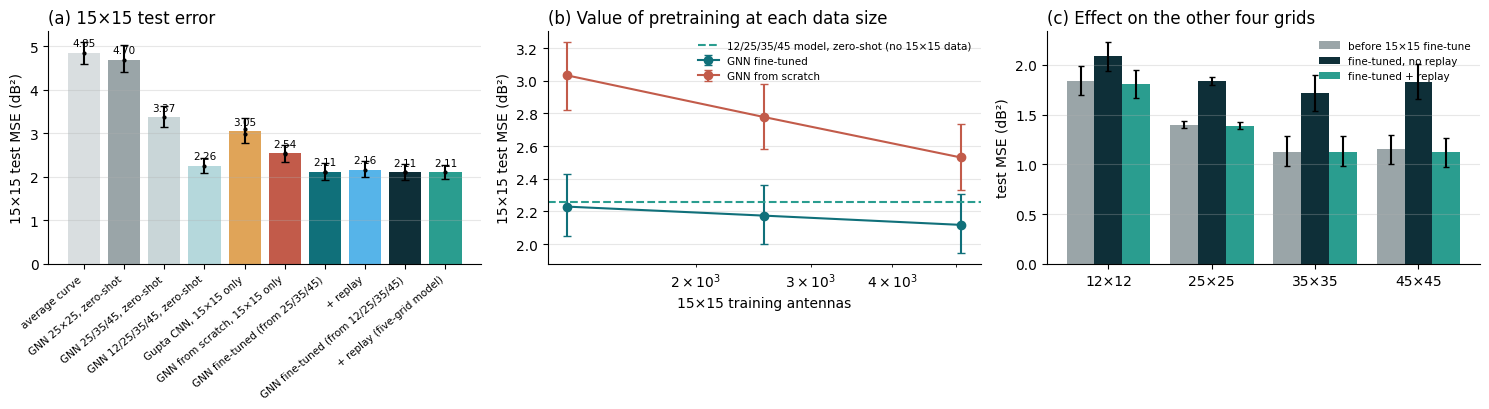

# Chunk 44 — Training, validating and testing on the 15×15 dataset

15×15 splits: pool 5,092 / val 638 / test 637. Selection on 15×15 val MSE only; one test touch; 95% stratified bootstrap intervals.

## 15×15 test
| model | MSE (dB²) | MAE (dB) | R² | AUROC | skill vs average curve |
|---|---|---|---|---|---|
| average_curve | 4.846 [4.581, 5.088] | 0.891 [0.876, 0.905] | 0.293 [0.277, 0.308] | nan | 0.000 |
| best_model | 4.695 [4.402, 5.027] | 0.817 [0.790, 0.846] | 0.315 [0.263, 0.363] | 0.819 | 0.031 |
| backbone_no55 | 3.365 [3.138, 3.621] | 0.689 [0.663, 0.715] | 0.509 [0.465, 0.548] | 0.824 | 0.305 |
| fourgrid_ch42 | 2.258 [2.093, 2.438] | 0.532 [0.514, 0.552] | 0.671 [0.642, 0.697] | 0.832 | 0.534 |
| cnn15_p100_s0 | 3.109 [2.892, 3.358] | 0.674 [0.653, 0.697] | 0.547 [0.511, 0.579] | 0.806 | 0.358 |
| cnn15_p100_s1 | 2.993 [2.768, 3.246] | 0.631 [0.610, 0.654] | 0.564 [0.529, 0.596] | 0.814 | 0.382 |
| ft15_from4_p100_s0 | 2.108 [1.938, 2.292] | 0.503 [0.483, 0.523] | 0.693 

In [17]:
# ── Figure and report ──
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
arms = [('average_curve', 'average curve', '#D9DEE0'), ('best_model', 'GNN 25×25, zero-shot', '#9AA5A8'),
        ('backbone_no55', 'GNN 25/35/45, zero-shot', '#C9D6D8'), ('fourgrid_ch42', 'GNN 12/25/35/45, zero-shot', '#B5D8DC'),
        ('cnn15', 'Gupta CNN, 15×15 only', '#E0A458'), ('scratch15', 'GNN from scratch, 15×15 only', '#C25B4A'),
        ('ft15', 'GNN fine-tuned (from 25/35/45)', '#10707A'), ('ft15_replay', '+ replay', '#56B4E9'),
        ('ft15_from4', 'GNN fine-tuned (from 12/25/35/45)', '#0E2F38'), ('ft15_from4_replay', '+ replay (five-grid model)', '#2A9D8F')]
xs, ys, lo, hi, cs, labels = [], [], [], [], [], []
for key, lab, col in arms:
    if key in REFS:
        mids = [key]
    else:
        mids = sorted(i for i in ids if i.rsplit('_p', 1)[0] == key and '_p100_' in i)
    vals = [v for v in (val(mm, 15, 'mse_db2') for mm in mids) if v is not None]
    if not vals: continue
    e = np.mean([v.estimate for v in vals]); xs.append(len(xs)); ys.append(e); cs.append(col); labels.append(lab)
    lo.append(e - min(v.lo for v in vals)); hi.append(max(v.hi for v in vals) - e)
    for v in vals: ax[0].plot(xs[-1], v.estimate, 'k.', ms=4, zorder=5)
ax[0].bar(xs, ys, color=cs, yerr=[lo, hi], capsize=3)
for x_, y_ in zip(xs, ys): ax[0].text(x_, y_ + 0.15, f'{y_:.2f}', ha='center', fontsize=7.5)
ax[0].set_xticks(xs); ax[0].set_xticklabels(labels, rotation=40, ha='right', fontsize=7.5); ax[0].set_ylabel('15×15 test MSE (dB²)')
ax[0].set_title('(a) 15×15 test error', loc='left')
for key, col, lab in (('ft15', '#10707A', 'fine-tuned'), ('scratch15', '#C25B4A', 'from scratch')):
    pts = [(f, val(f'{key}_p{int(f*100)}_s0', 15, 'mse_db2')) for f in (0.25, 0.5, 1.0)]
    pts = [(f, v) for f, v in pts if v is not None]
    if pts:
        n = [f * len(S[15]['pool']) for f, _ in pts]
        ax[1].errorbar(n, [v.estimate for _, v in pts], yerr=[[v.estimate - v.lo for _, v in pts], [v.hi - v.estimate for _, v in pts]],
                       marker='o', color=col, capsize=3, label=f'GNN {lab}')
z = val('fourgrid_ch42', 15, 'mse_db2')
if z is not None:
    ax[1].axhline(z.estimate, color='#2A9D8F', ls='--', label='12/25/35/45 model, zero-shot (no 15×15 data)')
ax[1].set_xscale('log'); ax[1].set_xlabel('15×15 training antennas'); ax[1].set_ylabel('15×15 test MSE (dB²)')
ax[1].set_title('(b) Value of pretraining at each data size', loc='left'); ax[1].legend(frameon=False, fontsize=7.5)
w = 0.27; G4 = (12, 25, 35, 45)
for j, (mid, col, lab) in enumerate((('fourgrid_ch42', '#9AA5A8', 'before 15×15 fine-tune'), ('ft15_from4_p100_s0', '#0E2F38', 'fine-tuned, no replay'),
                                    ('ft15_from4_replay_p100_s0', '#2A9D8F', 'fine-tuned + replay'))):
    v = [val(mid, N, 'mse_db2') for N in G4]
    if any(x is None for x in v): continue
    ax[2].bar(np.arange(4) + (j - 1) * w, [x.estimate for x in v], w, color=col, label=lab,
              yerr=[[x.estimate - x.lo for x in v], [x.hi - x.estimate for x in v]], capsize=2)
ax[2].set_xticks(range(4)); ax[2].set_xticklabels([f'{N}×{N}' for N in G4]); ax[2].set_ylabel('test MSE (dB²)')
ax[2].set_title('(c) Effect on the other four grids', loc='left'); ax[2].legend(frameon=False, fontsize=7.5)
for a in ax: a.grid(alpha=.3, axis='y'); a.spines[['top', 'right']].set_visible(False)
fig.tight_layout(); fig.savefig(OUT('ch44_results.png'), dpi=200); plt.show()

def fmt(mid, N, k):
    v = val(mid, N, k)
    if v is None: return '—'
    return f'{v.estimate:.3f}' if np.isnan(v.lo) else f'{v.estimate:.3f} [{v.lo:.3f}, {v.hi:.3f}]'
order = ['average_curve', 'best_model', 'backbone_no55', 'fourgrid_ch42'] + sorted(ids)
L = ['# Chunk 44 — Training, validating and testing on the 15×15 dataset', '',
     f'15×15 splits: pool {len(S[15]["pool"]):,} / val {len(S[15]["val"]):,} / test {len(S[15]["test"]):,}. '
     'Selection on 15×15 val MSE only; one test touch; 95% stratified bootstrap intervals.', '',
     '## 15×15 test', '| model | MSE (dB²) | MAE (dB) | R² | AUROC | skill vs average curve |', '|---|---|---|---|---|---|']
for mid in order:
    if val(mid, 15, 'mse_db2') is None: continue
    L.append(f'| {mid} | {fmt(mid, 15, "mse_db2")} | {fmt(mid, 15, "mae_db")} | {fmt(mid, 15, "r2")} | {fmt(mid, 15, "auroc")} | {fmt(mid, 15, "skill")} |')
L += ['', '## Other grids (forgetting check)', '| model | 12×12 MSE | 25×25 MSE | 35×35 MSE | 45×45 MSE |', '|---|---|---|---|---|']
for mid in ('backbone_no55', 'fourgrid_ch42', 'best_model', 'ft15_p100_s0', 'ft15_replay_p100_s0', 'ft15_from4_p100_s0', 'ft15_from4_replay_p100_s0'):
    if val(mid, 25, 'mse_db2') is not None:
        L.append(f'| {mid} | ' + ' | '.join(fmt(mid, N, 'mse_db2') for N in (12, 25, 35, 45)) + ' |')
L += ['', '## Paired comparisons (A − B, same test antennas)', PAIR.round(4).to_markdown(index=False), '',
      '## Pre-registered statements'] + [f'- **{k}:** {v}' for k, v in ANS.items()]
L += ['', '## Runs', pd.read_csv(RUNS).drop(columns=['checkpoint_sha256']).round(4).to_markdown(index=False)]
open(OUT('ch44_report.md'), 'w').write('\n'.join(L) + '\n'); print('\n'.join(L))

## 12. Guards
**What it checks:**
- one test touch
- every checkpoint matches its recorded SHA-256
- inputs unchanged and earlier files unmodified
- no run stopped by its epoch cap
- every output is named `ch44_*`

In [18]:
# ── Guards ──
fails = []
def guard(ok, msg):
    print(f"  [{'PASS' if ok else 'FAIL'}] {msg}")
    if not ok: fails.append(msg)
guard(TEST_TOUCHES == 1, 'TEST touched exactly once')
R2 = pd.read_csv(RUNS)
guard(all(sha(p) == h for p, h in zip(R2.checkpoint, R2.checkpoint_sha256)), 'every ch44 checkpoint matches its recorded SHA-256')
guard(all(sha(p) == h for p, h in READ_SHA.items() if not Path(p).name.startswith('ch44_')), f'input files unchanged ({len(READ_SHA)})')
guard(all(os.path.getmtime(p) == t for p, t in PRIOR.items() if os.path.exists(p)), f'no earlier file modified ({len(PRIOR)})')
guard(not R2.budget_limited.any(), 'no run stopped by its epoch cap' if not R2.budget_limited.any() else
      f'BUDGET-LIMITED runs: {list(R2[R2.budget_limited].run_id)}')
guard(all(Path(p).name.startswith('ch44_') for p in glob.glob(f'{ART}/ch44_*') + glob.glob(f'{CKPT}/ch44_*')), 'all outputs ch44_*')
assert not fails, fails
print('ALL GUARDS PASSED')

  [PASS] TEST touched exactly once
  [PASS] every ch44 checkpoint matches its recorded SHA-256
  [PASS] input files unchanged (38)
  [PASS] no earlier file modified (224)
  [PASS] no run stopped by its epoch cap
  [PASS] all outputs ch44_*
ALL GUARDS PASSED
